In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [10]:
# Read data
superset = "Lindsay"
folder = "KP_KL_Imaging"
segmentation = "stardist"

# Get project directory path
project_dir = Path(f"../data/{superset}/{folder}/{segmentation}").resolve()

# Read in predictions


In [11]:
# Read in masterfile and get modifications and folders
# Please be sure masterfile is uptodate
masterfile = pd.read_csv(f"../data/masterfile.csv")
# masterfile = masterfile[masterfile['cell_line_only'] == cell_line]
mods = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['cell_line']))
folder = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['folder']))
# masterfile
# folder

In [12]:
# Read in summary file
summary = pd.read_csv(f"{project_dir}_all_summary_predictions.csv")
# summary["cell_line"] = cell_line
summary["cell_line_mod"] = summary["file"].apply(lambda x: mods[x.split("_e")[0]])
summary["folder"] = summary["file"].apply(lambda x: folder[x.split("_e")[0]])
summary

,file,0,1,2,3,4,5,cells_with_micronuclei,cells_with_micronuclei_ratio,micronuclei_ratio,total_cells,total_micronuclei,cell_line_mod,folder
0,s01,37899.0,2211.0,195.0,39.0,14.0,NaN,2459.0,0.060930,0.068735,40358.0,2774.0,KL,KP_KL_Imaging
1,s02,37624.0,2208.0,201.0,25.0,8.0,NaN,2442.0,0.060949,0.067813,40066.0,2717.0,KL,KP_KL_Imaging
2,s04,36736.0,2549.0,204.0,44.0,13.0,3.0,2813.0,0.071127,0.079800,39549.0,3156.0,KL,KP_KL_Imaging
3,s05,38922.0,2657.0,243.0,35.0,5.0,1.0,2941.0,0.070253,0.078184,41863.0,3273.0,KL,KP_KL_Imaging
4,s06,41578.0,1905.0,78.0,5.0,3.0,NaN,1991.0,0.045698,0.047924,43569.0,2088.0,KP,KP_KL_Imaging
5,s07,39737.0,1768.0,66.0,3.0,NaN,NaN,1837.0,0.044186,0.045918,41574.0,1909.0,KP,KP_KL_Imaging
6,s08,41723.0,1855.0,68.0,1.0,NaN,NaN,1924.0,0.044081,0.045685,43647.0,1994.0,KP,KP_KL_Imaging
7,s09,45311.0,2085.0,91.0,4.0,NaN,NaN,2180.0,0.045903,0.047988,47491.0,2279.0,KP,KP_KL_Imaging


FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/KP_KL_Imaging/stardist/figures/micronuclei_ratio_KPKL.png'

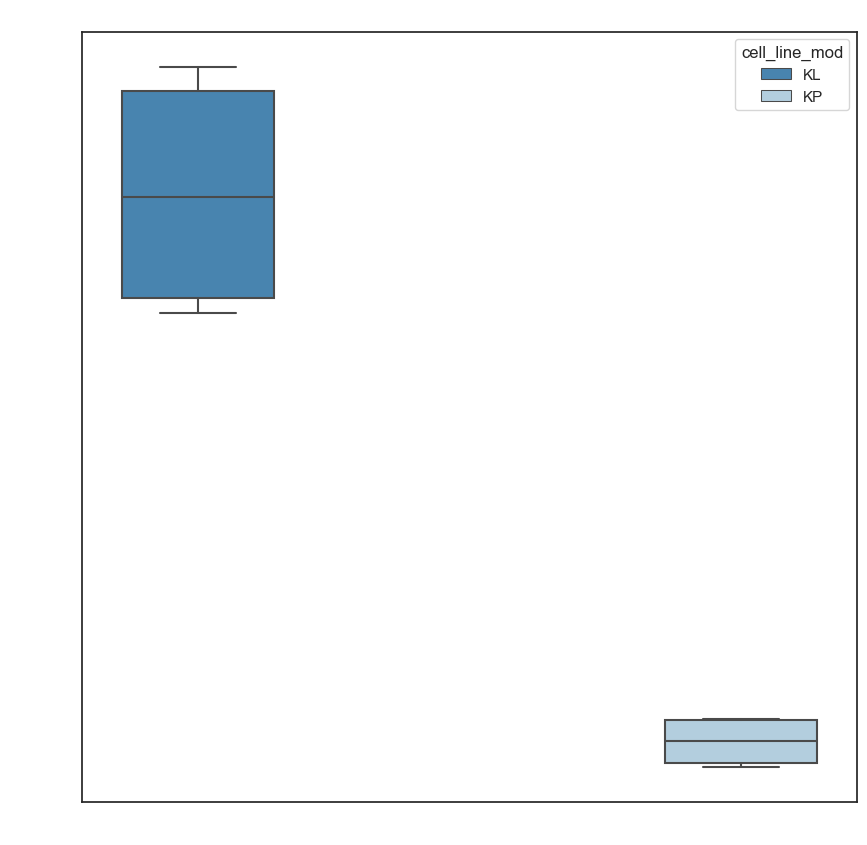

In [39]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'})
sns.set_style("white")

# Plot scatterplot of the micronuclei_ratio
fig, ax = plt.subplots(figsize=(10, 10))

# Sort results by the micronuclei_ratio
results = summary.sort_values(by="micronuclei_ratio", ascending=False)
sns.boxplot(data=results, x="cell_line_mod",  y="micronuclei_ratio", hue="cell_line_mod", palette="Blues_r", ax=ax)

# Rotate the 90 degrees the x-axis labels
plt.xticks(rotation=90)

ax.set_title(f"Micronuclei ratio = KP/KL", fontsize=14, color="white")
ax.set_xlabel(f"")
ax.set_ylabel(f"MN/Cell", fontsize="12", color="white")


fig.savefig(project_dir / "figures" / f"micronuclei_ratio_KPKL.png", dpi=300, bbox_inches="tight")
fig.savefig(project_dir / "figures" / f"micronuclei_ratio_KPKL.pdf", dpi=300, bbox_inches="tight")